Hello

# Data Cleaning for evolution of electric cars

### Import Packages

In [ ]:
import pandas as pd
import numpy as np
import plotly.express as px
import statsmodels
import plotly.io as pio
import matplotlib.pyplot as plt
import seaborn as sns
pio.renderers.default = "notebook"
import os
os.getcwd()

'/Users/alinaloacker/Documents/GitHub/Data_Science_Project'

### Load Data
You need to download the following file: https://www.dropbox.com/scl/fi/q3ei8expvumspa6gaii17/cars_total-ev.csv?rlkey=281ft04hxha9fi2jp7hfr3jjo&st=4efbs54j&dl=0

In [ ]:
df_cars_complete = pd.read_csv("cars_total-ev.csv")
df_cars_complete.head()


,STRUCTURE,STRUCTURE_ID,STRUCTURE_NAME,freq,Time frequency,unit,Unit of measure,mot_nrg,Motor energy,geo,...,TIME_PERIOD,Time,leg_form,Legal form,OBS_VALUE,Observation value,OBS_FLAG,Observation status (Flag) V2 structure,CONF_STATUS,Confidentiality status (flag)
0,dataflow,ESTAT:ROAD_EQS_CARPDA(1.0),Passenger cars by type of motor energy,A,Annual,NR,Number,ELC,Electricity,AL,...,2016,NaN,TOTAL,Total,13,NaN,NaN,NaN,NaN,NaN
1,dataflow,ESTAT:ROAD_EQS_CARPDA(1.0),Passenger cars by type of motor energy,A,Annual,NR,Number,ELC,Electricity,AL,...,2017,NaN,TOTAL,Total,48,NaN,NaN,NaN,NaN,NaN
2,dataflow,ESTAT:ROAD_EQS_CARPDA(1.0),Passenger cars by type of motor energy,A,Annual,NR,Number,ELC,Electricity,AL,...,2018,NaN,TOTAL,Total,102,NaN,NaN,NaN,NaN,NaN
3,dataflow,ESTAT:ROAD_EQS_CARPDA(1.0),Passenger cars by type of motor energy,A,Annual,NR,Number,ELC,Electricity,AL,...,2019,NaN,TOTAL,Total,124,NaN,NaN,NaN,NaN,NaN
4,dataflow,ESTAT:ROAD_EQS_CARPDA(1.0),Passenger cars by type of motor energy,A,Annual,NR,Number,ELC,Electricity,AL,...,2020,NaN,TOTAL,Total,362,NaN,NaN,NaN,NaN,NaN


### Restructure dataset

In [ ]:
print(df_cars_complete.columns.tolist())

['STRUCTURE', 'STRUCTURE_ID', 'STRUCTURE_NAME', 'freq', 'Time frequency', 'unit', 'Unit of measure', 'mot_nrg', 'Motor energy', 'geo', 'Geopolitical entity (reporting)', 'TIME_PERIOD', 'Time', 'leg_form', 'Legal form', 'OBS_VALUE', 'Observation value', 'OBS_FLAG', 'Observation status (Flag) V2 structure', 'CONF_STATUS', 'Confidentiality status (flag)']


In [ ]:
#Modyfiyng data set to only keep the variables I want, rename the remaining columns and get rid of the 2025 data
df_cars= (
    df_cars_complete[
        ["Geopolitical entity (reporting)",
            "TIME_PERIOD",
            "Motor energy",
            "OBS_VALUE" ]]
    .rename(columns={
        "Geopolitical entity (reporting)": "Country",
        "TIME_PERIOD": "Year",
        "Motor energy": "Index",
        "OBS_VALUE": "Cars"
    })
    .query("Year <= 2024")
    .pivot_table(
        index=["Country", "Year"],
        columns="Index",
        values="Cars"
    )
    .reset_index()
)

df_cars.head(10)

Index,Country,Year,Electricity,Total
0,Albania,2016,13.0,435613.0
1,Albania,2017,48.0,417426.0
2,Albania,2018,102.0,460027.0
3,Albania,2019,124.0,499590.0
4,Albania,2020,362.0,539497.0
5,Albania,2021,624.0,593280.0
6,Albania,2022,1245.0,639379.0
7,Albania,2023,2891.0,699337.0
8,Albania,2024,5722.0,775217.0
9,Austria,2016,9073.0,4821557.0


### Add the relative share of electric cars to the data-table

In [ ]:
#next I want to add a column that shows the share of electric cars in the total number of cars
df_cars["EV_share"] = (df_cars["Electricity"] /
    df_cars["Total"] * 100)
df_cars.head(10)

Index,Country,Year,Electricity,Total,EV_share
0,Albania,2016,13.0,435613.0,0.002984
1,Albania,2017,48.0,417426.0,0.011499
2,Albania,2018,102.0,460027.0,0.022173
3,Albania,2019,124.0,499590.0,0.024820
4,Albania,2020,362.0,539497.0,0.067100
5,Albania,2021,624.0,593280.0,0.105178
6,Albania,2022,1245.0,639379.0,0.194720
7,Albania,2023,2891.0,699337.0,0.413392
8,Albania,2024,5722.0,775217.0,0.738116
9,Austria,2016,9073.0,4821557.0,0.188176


### Removing rows with no values for Electricity or Total

In [ ]:
#check whether I have missing values
df_cars.isna().sum() #some missing values in electricity
df_cars[(df_cars['Electricity'].isna())] #for the moment, they don't matter, as I am not planning to use this countries for our analysis...
df_cars = df_cars.dropna()

### Filtering countries

In [ ]:
considered_countries = ["Norway", "Sweden"]
df_cars_filtered = df_cars[df_cars["Country"].isin(considered_countries)]
df_cars_filtered
df_cars_filtered.isna().sum() #I have no missing values :)

Index
Country        0
Year           0
Electricity    0
Total          0
EV_share       0
dtype: int64

In [ ]:
### Univariate analysis

### Absolute amount of cars in considered countries (total and electric)

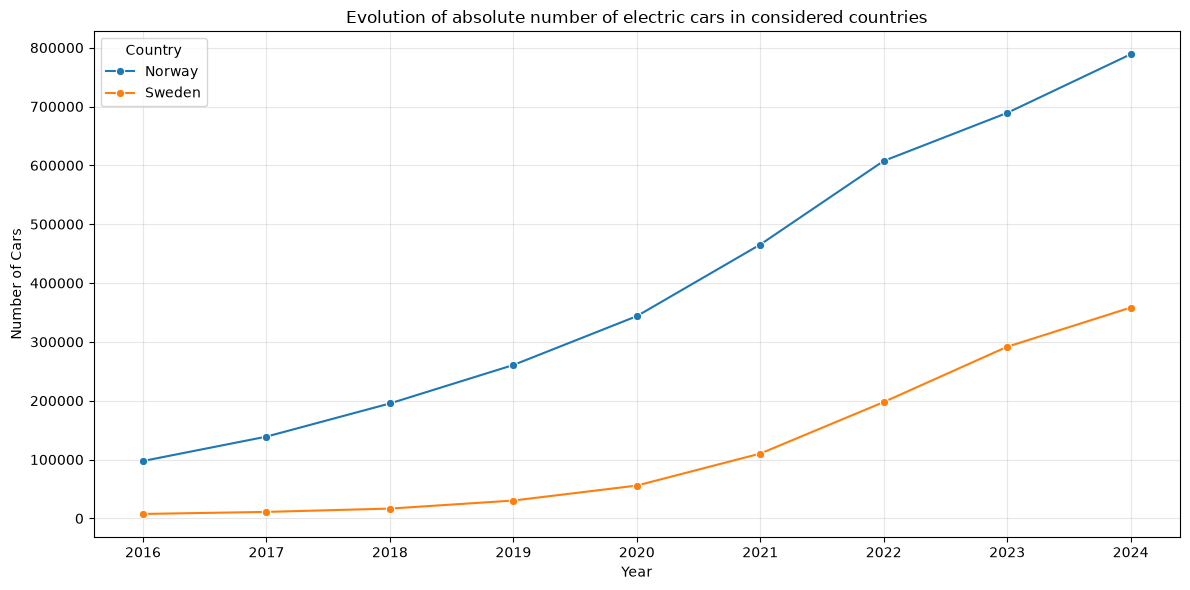

In [ ]:
plt.figure(figsize=(12, 6))

sns.lineplot(
    data=df_cars_filtered,
    x="Year",
    y="Electricity",
    hue="Country",
    marker="o"
)

plt.title("Evolution of absolute number of electric cars in considered countries")
plt.xlabel("Year")
plt.ylabel("Number of Cars")
plt.grid(True, alpha=0.3)
plt.legend(title="Country")
plt.tight_layout()
plt.show()

### Relative amount of cars in considered countries (total and electric)

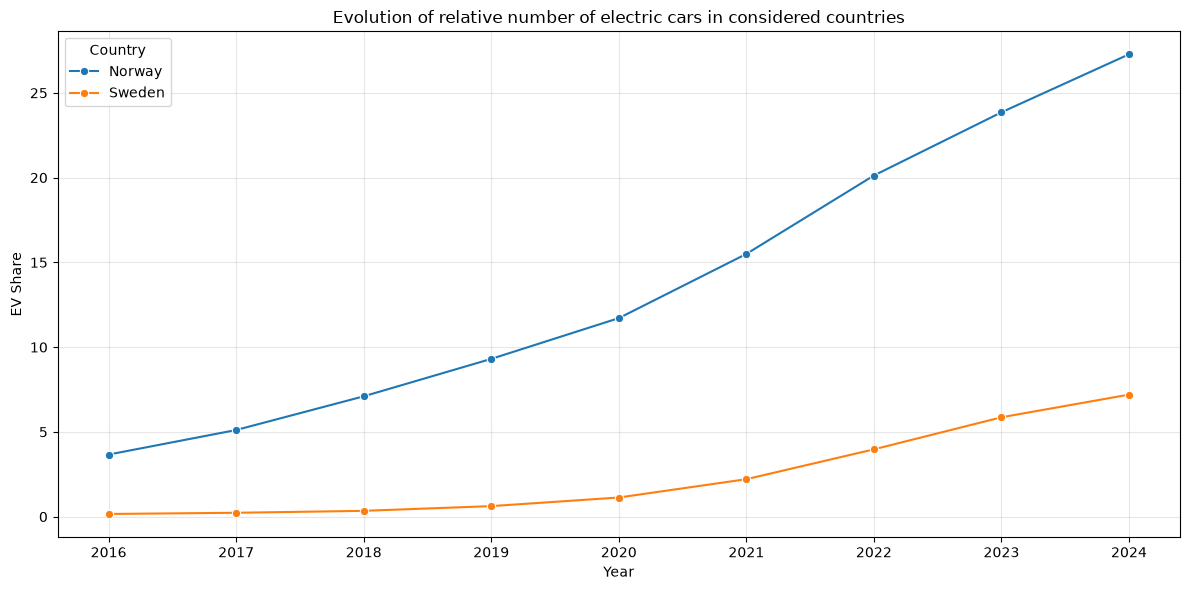

In [ ]:
plt.figure(figsize=(12, 6))

sns.lineplot(
    data=df_cars_filtered,
    x="Year",
    y="EV_share",
    hue="Country",
    marker="o"
)

plt.title("Evolution of relative number of electric cars in considered countries")
plt.xlabel("Year")
plt.ylabel("EV Share")
plt.grid(True, alpha=0.3)
plt.legend(title="Country")
plt.tight_layout()
plt.show()

# Data Cleaning for NOx emissions

### Import Packages

In [ ]:
import pandas as pd
import numpy as np
import plotly.express as px
import statsmodels
import plotly.io as pio
import matplotlib.pyplot as plt
import seaborn as sns
pio.renderers.default = "notebook"
import os
os.getcwd()

'/Users/maxlaurent/Documents/GitHub/Data_Science_Project'

### Load Data 

You need to download the following files :  
- Evolution of emissions of pollutants in countries : https://www.dropbox.com/scl/fi/za4x3lhjip10bxeanznh1/Emissions.csv?rlkey=duyun7b8bxs8lkxurxx4890qw&st=l58id7do&dl=0
- Evolution of population in countries : https://www.dropbox.com/scl/fi/v6p0gg3hes15e6pfwmjdl/Population.csv?rlkey=mljxr5nimv4sxmjkww1wgm47a&st=8x74mhyk&dl=0

In [ ]:
df = pd.read_csv("Emissions.csv",sep="\t",low_memory=False)

df.head()

,countryCode,country,pollutantName,sectorCode,year,value,unit,notation,parentSectorCode,sectorName
0,AT,Austria,As,1B1b,2017,NaN,t,NR,NATIONAL TOTAL,Fugitive emission from solid fuels: Solid fuel...
1,AT,Austria,As,1B1b,2018,NaN,t,NR,NATIONAL TOTAL,Fugitive emission from solid fuels: Solid fuel...
2,AT,Austria,As,1B1b,2019,NaN,t,NR,NATIONAL TOTAL,Fugitive emission from solid fuels: Solid fuel...
3,AT,Austria,As,1B1b,2020,NaN,t,NR,NATIONAL TOTAL,Fugitive emission from solid fuels: Solid fuel...
4,AT,Austria,As,1B1b,2021,NaN,t,NR,NATIONAL TOTAL,Fugitive emission from solid fuels: Solid fuel...


### Restructure dataset

In [ ]:
df.shape

(4511772, 10)

In [ ]:
df.columns.tolist()

['countryCode',
 'country',
 'pollutantName',
 'sectorCode',
 'year',
 'value',
 'unit',
 'notation',
 'parentSectorCode',
 'sectorName']

In [ ]:
useful_cols = ["country","pollutantName","year","value","unit","sectorName"]

df_bis = pd.read_csv("Emissions.csv",sep="\t",usecols=useful_cols,low_memory=False)

df_bis.head()

,country,pollutantName,year,value,unit,sectorName
0,Austria,As,2017,NaN,t,Fugitive emission from solid fuels: Solid fuel...
1,Austria,As,2018,NaN,t,Fugitive emission from solid fuels: Solid fuel...
2,Austria,As,2019,NaN,t,Fugitive emission from solid fuels: Solid fuel...
3,Austria,As,2020,NaN,t,Fugitive emission from solid fuels: Solid fuel...
4,Austria,As,2021,NaN,t,Fugitive emission from solid fuels: Solid fuel...


### Looking only at NOx emissions

In [ ]:
df_bis["pollutantName"].dropna().unique()

<StringArray>
[                        'As',                         'BC',
            'Benzo(a) Pyrene',      'Benzo(b) Fluoranthene',
      'benzo(k) Fluoranthene',                         'Cd',
                         'CO',   'Indeno (1,2,3-cd) Pyrene',
                        'NOx',                      'PM2.5',
                         'Zn',                         'Cr',
                         'Pb',                         'Se',
                        'NH3',                       'PCBs',
                         'Cu',                         'Ni',
                        'SOx', 'PCDD/PCDF (dioxins/furans)',
                      'NMVOC',                        'HCB',
                 'Total PAHs',                       'PM10',
                        'TSP',                         'Hg',
                    'Biomass',              'Gaseous Fuels',
               'Liquid Fuels',                'Other Fuels',
                'Solid Fuels']
Length: 31, dtype: str

In [ ]:
df_NOx = df_bis[df_bis["pollutantName"].str.upper().eq("NOX")].copy()

df_NOx.head()

,country,pollutantName,year,value,unit,sectorName
25945,Austria,NOx,2023,NaN,kt,Biological treatment of waste - Solid waste di...
25946,Austria,NOx,2024,NaN,kt,Biological treatment of waste - Solid waste di...
25947,Austria,NOx,1987,NaN,kt,Biological treatment of waste - Composting
25948,Austria,NOx,1988,NaN,kt,Biological treatment of waste - Composting
25949,Austria,NOx,1989,NaN,kt,Biological treatment of waste - Composting


### Removing rows with no values for NOx emissions

In [ ]:
df_NOx = df_NOx.dropna(subset=["value"]).copy()

df_NOx.head()

,country,pollutantName,year,value,unit,sectorName
26544,Austria,NOx,1990,0.019140,kt,Municipal waste incineration
26545,Austria,NOx,1991,0.019140,kt,Municipal waste incineration
26887,Austria,NOx,1987,0.017732,kt,Industrial waste incineration
26888,Austria,NOx,1988,0.017732,kt,Industrial waste incineration
26889,Austria,NOx,1989,0.017732,kt,Industrial waste incineration


### Considering values after 2000

In [ ]:
df_NOx = df_NOx[
    (df_NOx["year"] >= 2000)
].copy()

df_NOx

,country,pollutantName,year,value,unit,sectorName
26900,Austria,NOx,2000,0.024180,kt,Industrial waste incineration
26901,Austria,NOx,2001,0.024180,kt,Industrial waste incineration
26902,Austria,NOx,2002,0.024180,kt,Industrial waste incineration
26903,Austria,NOx,2003,0.024180,kt,Industrial waste incineration
26904,Austria,NOx,2004,0.024180,kt,Industrial waste incineration
...,...,...,...,...,...,...
4511625,EU27,NOx,2009,88.368465,kt,Agriculture/Forestry/Fishing: National fishing
4511667,EU27,NOx,2020,0.303015,kt,Fugitive emission from solid fuels: Solid fuel...
4511669,EU27,NOx,2023,0.002542,kt,Printing
4511751,EU27,NOx,2013,111.284276,kt,Urine and dung deposited by grazing animals


### Considering total emissions and road transport emissions in countries

In [ ]:
df_NOx["sectorName"].unique()

<StringArray>
[                                                      'Industrial waste incineration',
                                                         'Clinical waste incineration',
                                                                           'Cremation',
                                                               'Open burning of waste',
                                                                         'Adjustments',
   'National total for compliance assessment  (please specify all details in the IIR)',
                        'National total for the entire territory (based on fuel sold)',
                                                        'Municipal waste incineration',
                                              'Public electricity and heat production',
                                                                  'Petroleum refining',
 ...
                                                      'Crop residues applied to soils',
 'Other (incl

For NOx emissions within the countries, we will use :   
- 'National total for the entire territory (based on fuel sold)'.
- 'Road transport: Passenger cars'.   

In order to compare total emissions to passenger car emissions within countries.

Meaning of “based on fuel sold” : It means that emissions from fuel combustion are attributed to countries when the relevant fuel was sold in it, using the fuel quantity and pollutant-specific emission factors.

In [ ]:
total_sector = "National total for the entire territory (based on fuel sold)"

df_NOx_total = df_NOx[df_NOx["sectorName"].eq(total_sector)].copy()

df_NOx_total.head()

,country,pollutantName,year,value,unit,sectorName
30454,Austria,NOx,2000,211.911,kt,National total for the entire territory (based...
30455,Austria,NOx,2001,222.932,kt,National total for the entire territory (based...
30456,Austria,NOx,2002,231.171,kt,National total for the entire territory (based...
30457,Austria,NOx,2003,242.719,kt,National total for the entire territory (based...
30458,Austria,NOx,2004,243.363,kt,National total for the entire territory (based...


In [ ]:
road_transport = "Road transport: Passenger cars"

df_NOx_transport = df_NOx[df_NOx["sectorName"].eq(road_transport)].copy()

df_NOx_transport.head()

,country,pollutantName,year,value,unit,sectorName
158912,Austria,NOx,2000,39.8496,kt,Road transport: Passenger cars
158913,Austria,NOx,2001,42.4431,kt,Road transport: Passenger cars
158914,Austria,NOx,2002,48.9521,kt,Road transport: Passenger cars
158915,Austria,NOx,2003,54.2146,kt,Road transport: Passenger cars
158916,Austria,NOx,2004,56.6985,kt,Road transport: Passenger cars


### Filtering countries

In [ ]:
df_NOx_total["country"].unique()

<StringArray>
[      'Austria',       'Belgium',      'Bulgaria',        'Cyprus',
       'Czechia',       'Germany',       'Denmark',       'Estonia',
         'Spain',       'Finland',        'France',        'Greece',
       'Croatia',       'Hungary',       'Ireland',         'Italy',
     'Lithuania',    'Luxembourg',        'Latvia',         'Malta',
   'Netherlands',        'Poland',      'Portugal',       'Romania',
        'Sweden',      'Slovenia',      'Slovakia',   'Switzerland',
       'Iceland', 'Liechtenstein',        'Norway',       'Türkiye',
         'EEA32',          'EU27']
Length: 34, dtype: str

In [ ]:
considered_countries=["Norway","Sweden"]

df_NOx_total_clean = (df_NOx_total[df_NOx_total["country"].isin(considered_countries)]
                .sort_values(["country", "year"], ascending=[True, True]).reset_index(drop=True))

df_NOx_total_clean.head()

,country,pollutantName,year,value,unit,sectorName
0,Norway,NOx,2000,214.203,kt,National total for the entire territory (based...
1,Norway,NOx,2001,212.621,kt,National total for the entire territory (based...
2,Norway,NOx,2002,207.213,kt,National total for the entire territory (based...
3,Norway,NOx,2003,208.983,kt,National total for the entire territory (based...
4,Norway,NOx,2004,207.580,kt,National total for the entire territory (based...


In [ ]:
df_NOx_transport_clean = (df_NOx_transport[df_NOx_transport["country"].isin(considered_countries)]
                .sort_values(["country", "year"], ascending=[True, True]).reset_index(drop=True))

df_NOx_transport_clean.head()

,country,pollutantName,year,value,unit,sectorName
0,Norway,NOx,2000,18.6085,kt,Road transport: Passenger cars
1,Norway,NOx,2001,17.4360,kt,Road transport: Passenger cars
2,Norway,NOx,2002,16.4611,kt,Road transport: Passenger cars
3,Norway,NOx,2003,15.5097,kt,Road transport: Passenger cars
4,Norway,NOx,2004,14.9234,kt,Road transport: Passenger cars


### Univariate analysis

#### Total emissions of NOx in considered countries (all sectors)

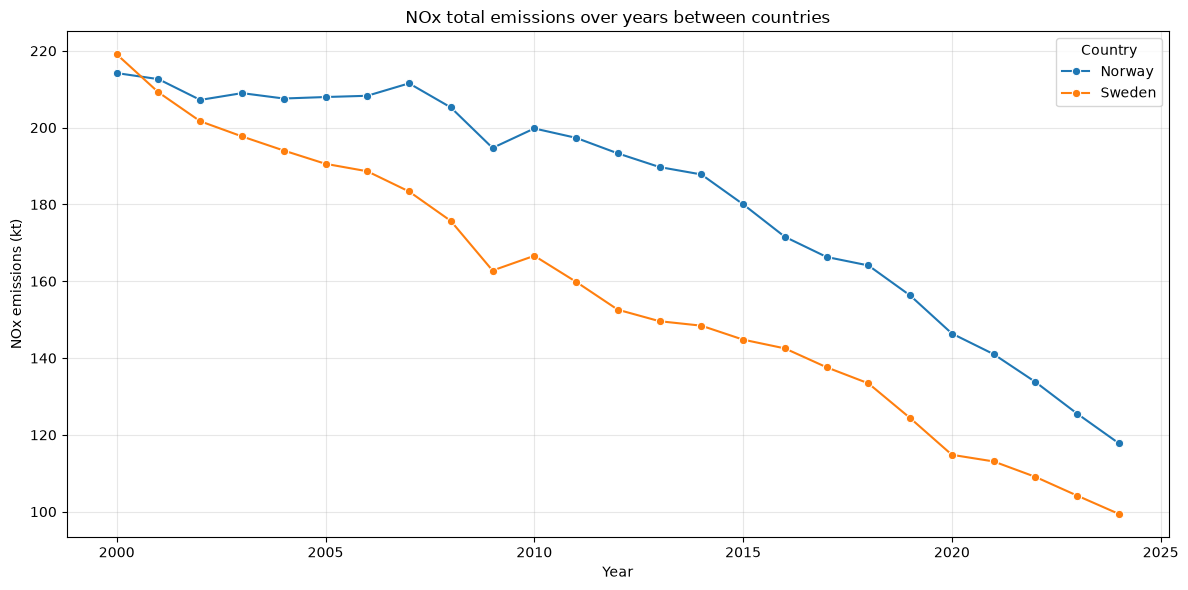

In [ ]:
plt.figure(figsize=(12, 6))

sns.lineplot(
    data=df_NOx_total_clean,
    x="year",
    y="value",
    hue="country",
    marker="o"
)

plt.title("NOx total emissions over years between countries")
plt.xlabel("Year")
plt.ylabel("NOx emissions (kt)")
plt.grid(True, alpha=0.3)
plt.legend(title="Country")
plt.tight_layout()
plt.show()

#### Road transport related NOx emissions in countries

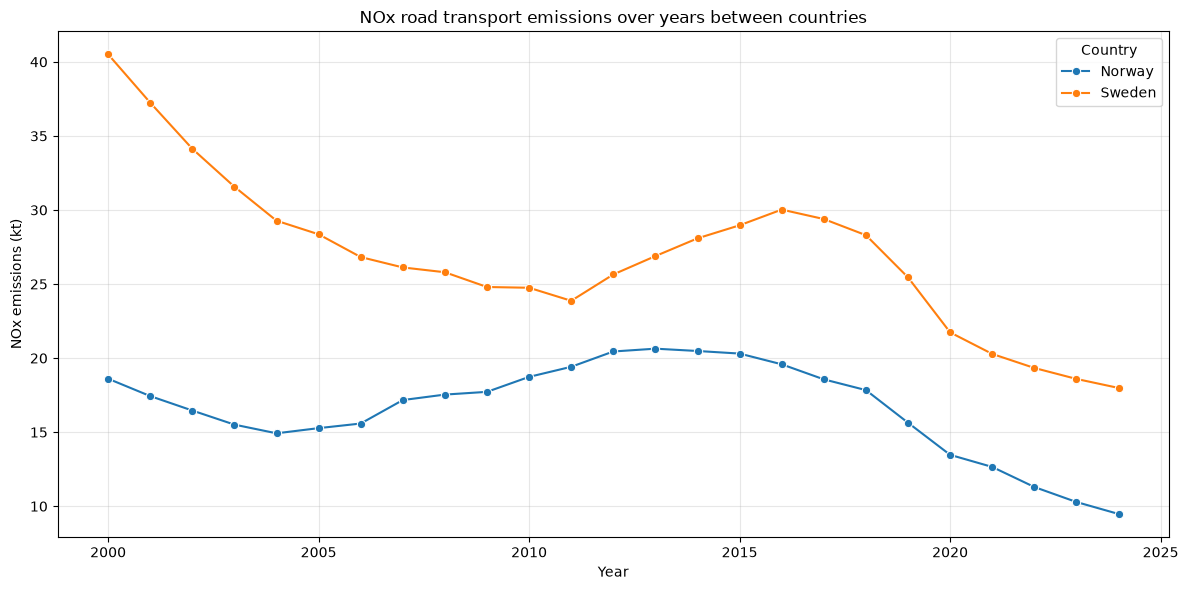

In [ ]:
plt.figure(figsize=(12, 6))

sns.lineplot(
    data=df_NOx_transport_clean,
    x="year",
    y="value",
    hue="country",
    marker="o"
)

plt.title("NOx road transport emissions over years between countries")
plt.xlabel("Year")
plt.ylabel("NOx emissions (kt)")
plt.grid(True, alpha=0.3)
plt.legend(title="Country")
plt.tight_layout()
plt.show()

#### Share of NOx emissions related to road transport

In [ ]:
final_NOx_df = (
    df_NOx_transport_clean
    .groupby(["country", "year"], as_index=False)["value"]
    .sum()
    .rename(columns={
        "value": "Road transport emissions (kt)"
    })
    .merge(
        df_NOx_total_clean[
            ["country", "year", "value"]
        ].rename(columns={
            "value": "Total NOx emissions (kt)"
        }),
        on=["country", "year"],
        how="inner"
    )
    .assign(
        Road_transport_share_pct=lambda x: (
            x["Road transport emissions (kt)"]
            / x["Total NOx emissions (kt)"]
            * 100
        )
    )
)

final_NOx_df.head()

,country,year,Road transport emissions (kt),Total NOx emissions (kt),Road_transport_share_pct
0,Norway,2000,18.6085,214.203,8.687320
1,Norway,2001,17.4360,212.621,8.200507
2,Norway,2002,16.4611,207.213,7.944048
3,Norway,2003,15.5097,208.983,7.421513
4,Norway,2004,14.9234,207.580,7.189228


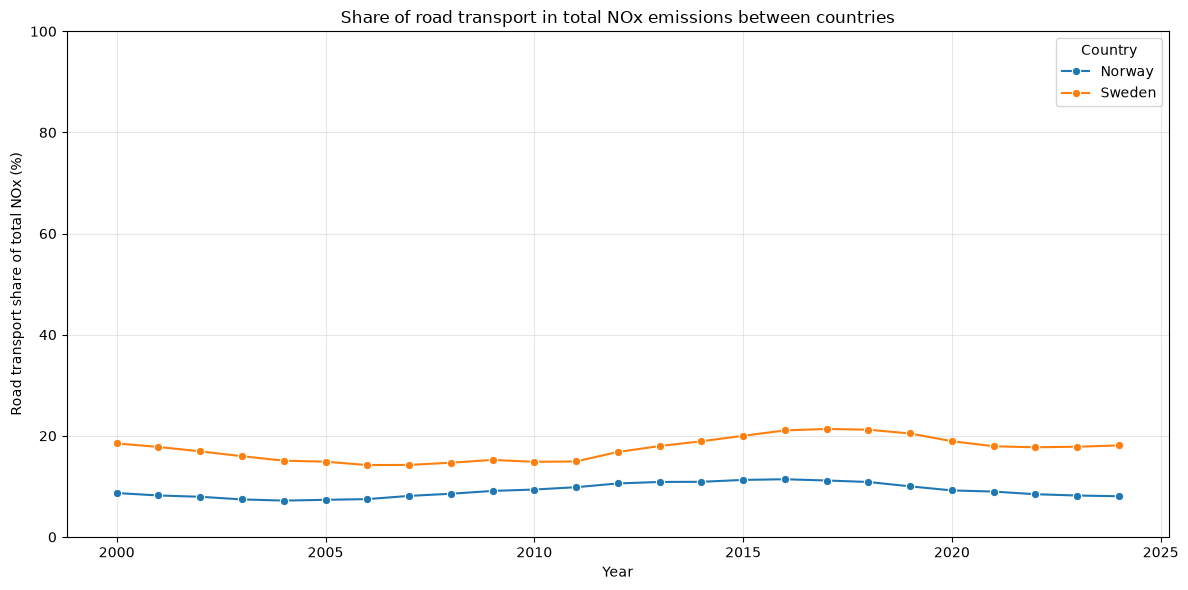

In [ ]:
plt.figure(figsize=(12, 6))

sns.lineplot(
    data=final_NOx_df,
    x="year",
    y="Road_transport_share_pct",
    hue="country",
    marker="o"
)

plt.title("Share of road transport in total NOx emissions between countries")
plt.xlabel("Year")
plt.ylabel("Road transport share of total NOx (%)")
plt.ylim(0, 100)
plt.grid(True, alpha=0.3)
plt.legend(title="Country")
plt.tight_layout()
plt.show()

#### Taking population into account

In [ ]:
df = pd.read_csv("Population.csv", sep=";", low_memory=False)

df.head()

,Country Name,Country Code,Indicator Name,Indicator Code,1960,1961,1962,1963,1964,1965,...,2017,2018,2019,2020,2021,2022,2023,2024,2025,Unnamed: 70
0,Aruba,ABW,"Population, total",SP.POP.TOTL,54922.0,55578.0,56320.0,57002.0,57619.0,58190.0,...,108735.0,108908.0,109203.0,108587.0,107700.0,107310.0,107359.0,107995.0,108785.0,NaN
1,Africa Eastern and Southern,AFE,"Population, total",SP.POP.TOTL,130075728.0,133534923.0,137171659.0,140945536.0,144904094.0,149033472.0,...,640058741.0,657801085.0,675950189.0,694446100.0,713090928.0,731821393.0,750491370.0,769280888.0,788844284.0,NaN
2,Afghanistan,AFG,"Population, total",SP.POP.TOTL,9035043.0,9214083.0,9404406.0,9604487.0,9814318.0,10036008.0,...,35688935.0,36743039.0,37856121.0,39068979.0,40000412.0,40578842.0,41454761.0,42647492.0,43844111.0,NaN
3,Africa Western and Central,AFW,"Population, total",SP.POP.TOTL,97630925.0,99706674.0,101854756.0,104089175.0,106384410.0,108754449.0,...,440150152.0,451395343.0,462522286.0,473687685.0,484978794.0,496366058.0,508318102.0,520655398.0,532809933.0,NaN
4,Angola,AGO,"Population, total",SP.POP.TOTL,5231654.0,5301583.0,5354310.0,5408320.0,5464187.0,5521981.0,...,30234839.0,31297155.0,32375632.0,33451132.0,34532429.0,35635029.0,36749906.0,37885849.0,39040039.0,NaN


In [ ]:
df.shape

(265, 71)

### Using only useful colums

In [ ]:
df.columns.to_list()

['Country Name',
 'Country Code',
 'Indicator Name',
 'Indicator Code',
 '1960',
 '1961',
 '1962',
 '1963',
 '1964',
 '1965',
 '1966',
 '1967',
 '1968',
 '1969',
 '1970',
 '1971',
 '1972',
 '1973',
 '1974',
 '1975',
 '1976',
 '1977',
 '1978',
 '1979',
 '1980',
 '1981',
 '1982',
 '1983',
 '1984',
 '1985',
 '1986',
 '1987',
 '1988',
 '1989',
 '1990',
 '1991',
 '1992',
 '1993',
 '1994',
 '1995',
 '1996',
 '1997',
 '1998',
 '1999',
 '2000',
 '2001',
 '2002',
 '2003',
 '2004',
 '2005',
 '2006',
 '2007',
 '2008',
 '2009',
 '2010',
 '2011',
 '2012',
 '2013',
 '2014',
 '2015',
 '2016',
 '2017',
 '2018',
 '2019',
 '2020',
 '2021',
 '2022',
 '2023',
 '2024',
 '2025',
 'Unnamed: 70']

In [ ]:
year_cols = [str(year) for year in range(2000, 2025)]

useful_cols = ["Country Name"] + year_cols

df_bis = pd.read_csv("Population.csv",sep=";",usecols=useful_cols,low_memory=False)

df_bis.head()

,Country Name,2000,2001,2002,2003,2004,2005,2006,2007,2008,...,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024
0,Aruba,90588.0,91439.0,92074.0,93128.0,95138.0,97635.0,99405.0,100150.0,100917.0,...,107906.0,108727.0,108735.0,108908.0,109203.0,108587.0,107700.0,107310.0,107359.0,107995.0
1,Africa Eastern and Southern,406156661.0,416807868.0,427820358.0,439173286.0,450928044.0,463076637.0,475606210.0,488580707.0,502070763.0,...,607123269.0,623369401.0,640058741.0,657801085.0,675950189.0,694446100.0,713090928.0,731821393.0,750491370.0,769280888.0
2,Afghanistan,20130327.0,20284307.0,21378117.0,22733049.0,23560654.0,24404567.0,25424094.0,25909852.0,26482622.0,...,33831764.0,34700612.0,35688935.0,36743039.0,37856121.0,39068979.0,40000412.0,40578842.0,41454761.0,42647492.0
3,Africa Western and Central,274612131.0,282407479.0,290455651.0,298744790.0,307309912.0,316156999.0,325222154.0,334544275.0,344153435.0,...,417536152.0,428797338.0,440150152.0,451395343.0,462522286.0,473687685.0,484978794.0,496366058.0,508318102.0,520655398.0
4,Angola,16194869.0,16747208.0,17327699.0,17943712.0,18600423.0,19291161.0,20015279.0,20778561.0,21578655.0,...,28157798.0,29183070.0,30234839.0,31297155.0,32375632.0,33451132.0,34532429.0,35635029.0,36749906.0,37885849.0


### Filtering countries

In [ ]:
df_bis["Country Name"].unique()

<StringArray>
[                      'Aruba', 'Africa Eastern and Southern',
                 'Afghanistan',  'Africa Western and Central',
                      'Angola',                     'Albania',
                     'Andorra',                  'Arab World',
        'United Arab Emirates',                   'Argentina',
 ...
       'Virgin Islands (U.S.)',                    'Viet Nam',
                     'Vanuatu',                       'World',
                       'Samoa',                      'Kosovo',
                 'Yemen, Rep.',                'South Africa',
                      'Zambia',                    'Zimbabwe']
Length: 265, dtype: str

In [ ]:
considered_countries=["Norway","Sweden"]

df_population = (df_bis[df_bis["Country Name"].isin(considered_countries)]
                 .rename(columns={"Country Name": "country"}).reset_index(drop=True))
df_population.head()

,country,2000,2001,2002,2003,2004,2005,2006,2007,2008,...,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024
0,Norway,4490967.0,4513751.0,4538159.0,4564855.0,4591910.0,4623291.0,4660677.0,4709153.0,4768212.0,...,5188607.0,5234519.0,5276968.0,5311916.0,5347896.0,5379475.0,5408320.0,5457127.0,5519601.0,5572279.0
1,Sweden,8872109.0,8895960.0,8924958.0,8958229.0,8993531.0,9029572.0,9080505.0,9148092.0,9219637.0,...,9799186.0,9923085.0,10057698.0,10175214.0,10278887.0,10353442.0,10415811.0,10486941.0,10536632.0,10569709.0


In [ ]:
final_pop_df = (
    df_population
    .melt(
        id_vars="country",
        var_name="year",
        value_name="population"
    )
    .assign(
        year=lambda df: pd.to_numeric(df["year"]),
        population=lambda df: pd.to_numeric(
            df["population"],
            errors="coerce"
        )
    )
    .sort_values(["country", "year"])
    .reset_index(drop=True)
)

final_pop_df.head()

,country,year,population
0,Norway,2000,4490967.0
1,Norway,2001,4513751.0
2,Norway,2002,4538159.0
3,Norway,2003,4564855.0
4,Norway,2004,4591910.0


In [ ]:
# Fusion des deux DataFrames
final_df = final_NOx_df.merge(
    final_pop_df,
    on=["country", "year"],
    how="left"
)

# Calculs en tonnes par habitant
final_df["Road transport emissions per capita (t)"] = (
    final_df["Road transport emissions (kt)"] * 1000
    / final_df["population"]
)

final_df["Total NOx emissions per capita (t)"] = (
    final_df["Total NOx emissions (kt)"] * 1000
    / final_df["population"]
)

# Ordre final des colonnes
final_df = final_df[
    [
        "country",
        "year",
        "population",
        "Road transport emissions (kt)",
        "Road transport emissions per capita (t)",
        "Total NOx emissions (kt)",
        "Total NOx emissions per capita (t)",
        "Road_transport_share_pct"
    ]
]

final_df.head()

,country,year,population,Road transport emissions (kt),Road transport emissions per capita (t),Total NOx emissions (kt),Total NOx emissions per capita (t),Road_transport_share_pct
0,Norway,2000,4490967.0,18.6085,0.004144,214.203,0.047696,8.687320
1,Norway,2001,4513751.0,17.4360,0.003863,212.621,0.047105,8.200507
2,Norway,2002,4538159.0,16.4611,0.003627,207.213,0.045660,7.944048
3,Norway,2003,4564855.0,15.5097,0.003398,208.983,0.045781,7.421513
4,Norway,2004,4591910.0,14.9234,0.003250,207.580,0.045206,7.189228


#### Total emissions of NOx per capita in countries (all sectors)

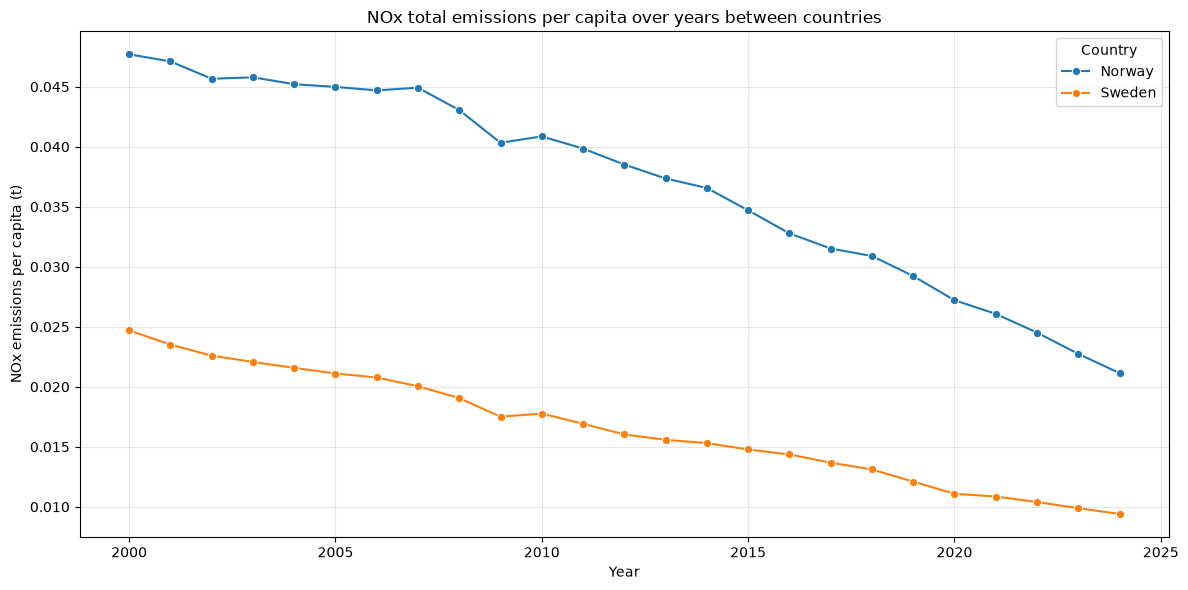

In [ ]:
plt.figure(figsize=(12, 6))

sns.lineplot(
    data=final_df,
    x="year",
    y="Total NOx emissions per capita (t)",
    hue="country",
    marker="o"
)

plt.title("NOx total emissions per capita over years between countries")
plt.xlabel("Year")
plt.ylabel("NOx emissions per capita (t)")
plt.grid(True, alpha=0.3)
plt.legend(title="Country")
plt.tight_layout()
plt.show()

#### Road transport related NOx emissions per capita in countries

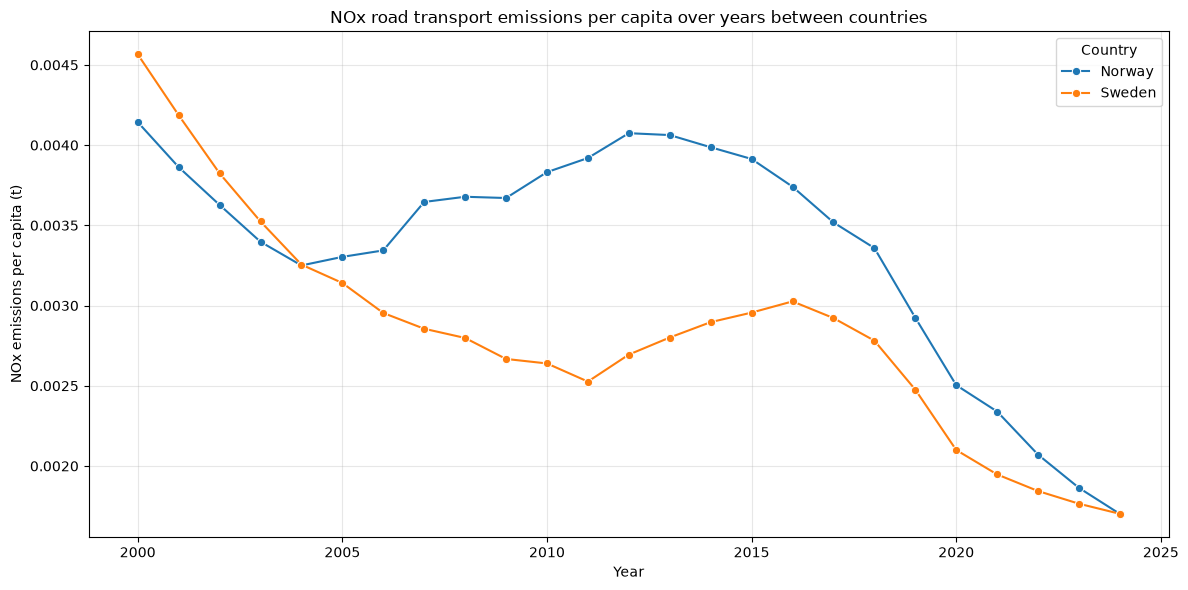

In [ ]:
plt.figure(figsize=(12, 6))

sns.lineplot(
    data=final_df,
    x="year",
    y="Road transport emissions per capita (t)",
    hue="country",
    marker="o"
)

plt.title("NOx road transport emissions per capita over years between countries")
plt.xlabel("Year")
plt.ylabel("NOx emissions per capita (t)")
plt.grid(True, alpha=0.3)
plt.legend(title="Country")
plt.tight_layout()
plt.show()